In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [42]:
df=pd.read_csv("..\\data\\yield_df_cleaned.csv")
df.sample(10)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
24474,Turkey,"Rice, paddy",1998,52601,593.0,30162.00,14.48
3644,Brazil,"Rice, paddy",2006,38798,1761.0,238716.00,24.57
25249,United Kingdom,Wheat,1993,73282,1220.0,32387.00,7.59
18400,Mexico,"Rice, paddy",2006,47857,758.0,50891.95,16.37
24135,Thailand,Wheat,2005,7816,1622.0,43831.00,27.92
23991,Tajikistan,"Rice, paddy",2007,30707,691.0,247.90,8.69
8069,Eritrea,Sorghum,2007,10693,383.0,27.63,24.70
9387,Guyana,Yams,2010,123760,2387.0,211.83,27.87
9344,Guyana,Sweet potatoes,2002,16667,2387.0,289.90,27.17
19011,Morocco,Sorghum,2001,5845,346.0,13842.57,18.73


In [43]:
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [44]:
df.Item.unique()

array(['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

In [45]:
df['Item'] = df['Item'].replace('Rice, paddy', 'Rice')

In [46]:
df.Item.unique()

array(['Maize', 'Potatoes', 'Rice', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

In [47]:
X = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']
X.head()

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,1485.0,121.0,16.37
1,Albania,Potatoes,1990,1485.0,121.0,16.37
2,Albania,Rice,1990,1485.0,121.0,16.37
3,Albania,Sorghum,1990,1485.0,121.0,16.37
4,Albania,Soybeans,1990,1485.0,121.0,16.37


In [48]:
y.head()

0    36613
1    66667
2    23333
3    12500
4     7000
Name: hg/ha_yield, dtype: int64

In [49]:
X = pd.get_dummies(X,columns=['Area','Item'],drop_first=True,dtype=int)
X

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,Area_Australia,Area_Austria,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,Item_Rice,Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25927,2013,657.0,2550.07,19.76,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
25928,2013,657.0,2550.07,19.76,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
25929,2013,657.0,2550.07,19.76,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
25930,2013,657.0,2550.07,19.76,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


In [50]:
joblib.dump(X.columns.tolist(), '../models/yield_columns.pkl')

['../models/yield_columns.pkl']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [52]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [53]:
lr.coef_

array([ 1.10012094e+03, -6.10471589e+00,  2.37210996e-02,  8.35595100e+01,
       -1.04273923e+04, -5.16302436e+04,  1.03134250e+04, -1.53344742e+04,
        4.40282553e+04,  5.11768070e+04, -2.43787311e+04, -3.93405556e+04,
       -2.29249685e+04, -6.59592621e+03, -1.03371112e+04,  1.30808550e+05,
       -2.33199837e+04, -8.31171610e+03, -1.16604687e+04, -5.79756642e+04,
       -4.61946773e+04, -3.88770958e+04, -4.09283827e+03, -7.12375661e+04,
        1.24200882e+04, -6.63954274e+03,  2.94337240e+03,  1.10286203e+05,
       -3.42254692e+04, -4.06269893e+04,  4.23737191e+04,  6.58020776e+03,
       -5.71490891e+04, -2.58891826e+04,  3.07234459e+04,  5.57158130e+04,
        7.34740664e+04, -3.04077965e+04,  2.33029849e+04,  6.77219190e+03,
       -4.93902538e+04, -2.74521893e+04, -5.64213031e+04, -2.44493924e+04,
        6.14057802e+03,  3.94766915e+03,  5.67451146e+02, -1.91216002e+04,
        9.70692700e+04,  3.43978689e+04,  1.40182577e+04,  5.16028323e+04,
       -1.81652230e+04, -

In [54]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse = mean_squared_error(y_test, y_pred_lr)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred_lr)

print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MSE : 1840143038.057658
RMSE: 42896.88844260919
R2  : 0.7475340610859975


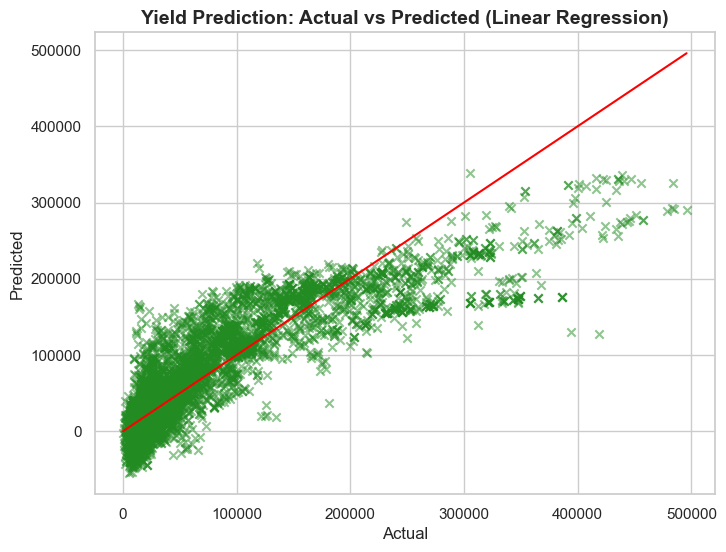

In [55]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.set_theme(style="whitegrid", palette="GnBu")
plt.scatter(y_test,y_pred_lr,alpha=0.5,c='forestgreen',marker='x')

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],c='Red')

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Yield Prediction: Actual vs Predicted (Linear Regression)',fontweight='bold',fontsize=14)

plt.show()

In [56]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred_rf = rf.predict(X_test)

In [58]:
mse_rf = mean_squared_error(y_test,y_pred_rf)
rmse_rf = mse_rf**0.5
r2_rf = r2_score(y_test,y_pred_rf)

print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MSE : 89409111.97382098
RMSE: 9455.639162627822
R2  : 0.9877331517522875


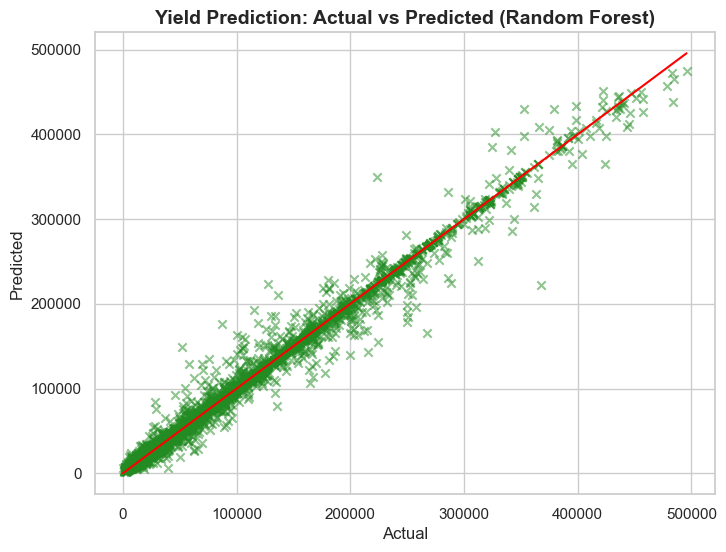

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_rf,alpha=0.5,c='forestgreen',marker='x')

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],c='Red')

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Yield Prediction: Actual vs Predicted (Random Forest)',fontweight='bold',fontsize=14)

plt.show()

In [60]:
from sklearn.tree import DecisionTreeRegressor as DTR

dt = DTR(max_depth=None)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [61]:
y_pred_dt = dt.predict(X_test)

In [62]:
mse_dt = mean_squared_error(y_test,y_pred_dt)
rmse_dt = mse_dt**0.5
r2_dt = r2_score(y_test,y_pred_dt)

print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2  :", r2_dt)

MSE : 144742087.06458452
RMSE: 12030.880560648275
R2  : 0.980141518264958


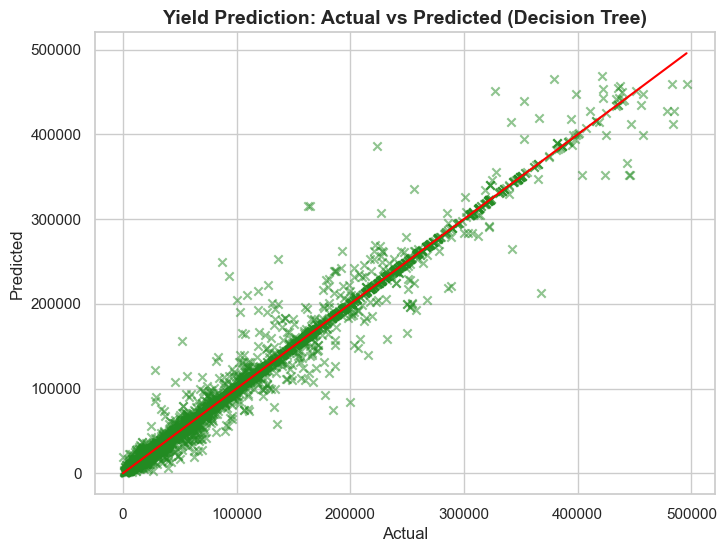

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_dt,alpha=0.5,c='forestgreen',marker='x')

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],c='Red')

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Yield Prediction: Actual vs Predicted (Decision Tree)',fontweight='bold',fontsize=14)

plt.show()

In [64]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Decision Tree','Random Forest'],
    'MSE':[mse,mse_dt,mse_rf],
    'RMSE':[rmse,rmse_dt,rmse_rf],
    'R2':[r2,r2_dt,r2_rf]
})

comparison

,Model,MSE,RMSE,R2
0,Linear Regression,1.840143e+09,42896.888443,0.747534
1,Decision Tree,1.447421e+08,12030.880561,0.980142
2,Random Forest,8.940911e+07,9455.639163,0.987733


In [65]:
importance_dt = pd.DataFrame({
    'Feature':X.columns,
    'Importance':dt.feature_importances_
})

importance_dt = importance_dt.sort_values(by='Importance',ascending=False)
importance_dt

,Feature,Importance
106,Item_Potatoes,3.716921e-01
2,pesticides_tonnes,7.298666e-02
107,Item_Rice,6.743380e-02
110,Item_Sweet potatoes,6.550333e-02
45,Area_India,5.773091e-02
...,...,...
25,Area_Colombia,4.553295e-07
7,Area_Armenia,3.058907e-07
12,Area_Bahrain,1.755182e-07
33,Area_Estonia,5.515368e-09


In [66]:
importance_rf = pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_})
importance_rf = importance_rf.sort_values(by='Importance',ascending=False)
importance_rf

,Feature,Importance
106,Item_Potatoes,0.370388
2,pesticides_tonnes,0.078044
107,Item_Rice,0.067392
110,Item_Sweet potatoes,0.065083
45,Area_India,0.053754
...,...,...
96,Area_Tunisia,0.000015
7,Area_Armenia,0.000015
33,Area_Estonia,0.000012
66,Area_Montenegro,0.000007


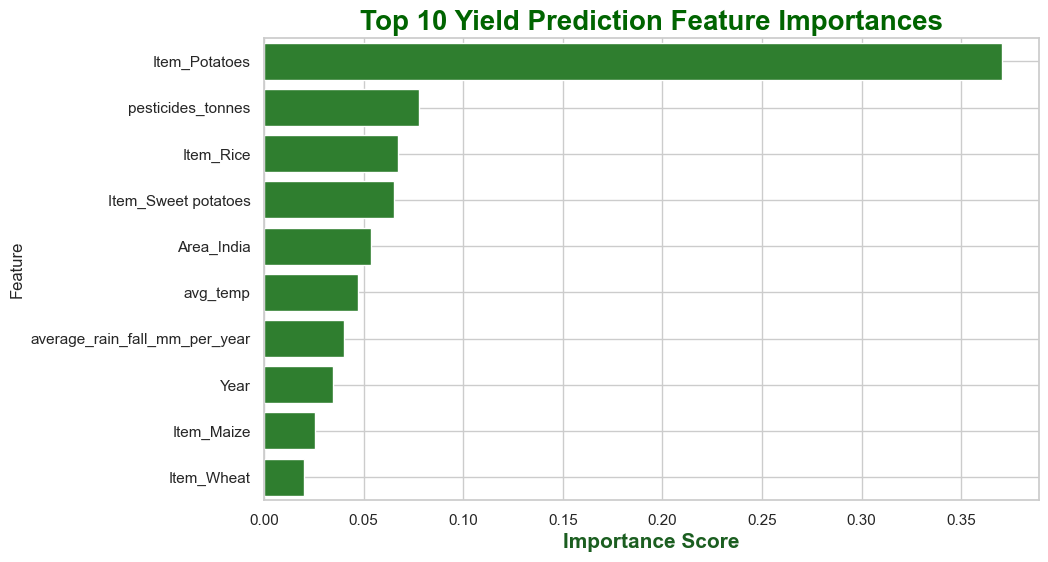

In [67]:
plt.figure(figsize=(10,6))
top10=importance_rf.head(10)
sns.barplot(data=top10,x=top10['Importance'],y=top10['Feature'],color='forestgreen')
plt.title('Top 10 Yield Prediction Feature Importances',fontsize=20,fontweight='bold',color='darkgreen')
plt.xlabel('Importance Score',fontsize=15,fontweight='bold',color='#1B5E20')
plt.grid(True)

Saving the models

In [68]:
joblib.dump(rf, '../models/yield_prediction_model_RFR.pkl')

['../models/yield_prediction_model_RFR.pkl']

In [69]:
df.sample().drop(columns='hg/ha_yield')

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
20618,Pakistan,Sweet potatoes,2002,494.0,10881.83,27.88


In [70]:
df.iloc[3782,3]

np.int64(40800)